In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

In [2]:
# -- Data ----------------------------------------------------

CONTROL_POINTS = np.array([
    [0, 0, 1],   # P0
    [0, 4, 1],   # P1
    [4, 0, 1],   # P2
    [4, 4, 1],   # P3
    [5, 4, 1],   # P4
])

U_HIGHLIGHT = np.round(np.arange(0.0, 1.1, 0.1), 2)

In [3]:
# -- Bezier Computation --------------------------------------

class BezierQuartic:
    """Quartic Bezier curve from five control points."""

    def __init__(self, points: np.ndarray):
        self.points = points
        self.p0 = points[0]
        self.p1 = points[1]
        self.p2 = points[2]
        self.p3 = points[3]
        self.p4 = points[4]

    def _basis(self, u: float) -> tuple:
        """Return degree-4 Bernstein basis values at u."""
        v  = 1 - u
        b0 = v ** 4
        b1 = 4 * u * v ** 3
        b2 = 6 * u ** 2 * v ** 2
        b3 = 4 * u ** 3 * v
        b4 = u ** 4
        return b0, b1, b2, b3, b4

    def point(self, u: float) -> np.ndarray:
        """Return curve point at parameter u."""
        b0, b1, b2, b3, b4 = self._basis(u)
        return (
            b0 * self.p0
            + b1 * self.p1
            + b2 * self.p2
            + b3 * self.p3
            + b4 * self.p4
        )

    def curve(self, n: int = 300) -> np.ndarray:
        """Return array of smooth curve points."""
        u_vals = np.linspace(0, 1, n)
        return np.array([self.point(u) for u in u_vals])

    def highlight_points(
        self, u_list: np.ndarray
    ) -> np.ndarray:
        """Return curve points for given u values."""
        return np.array([
            self.point(u) for u in u_list
        ])


In [4]:
# -- Plot ----------------------------------------------------

class BezierPlot3D:
    """3D plot for a quartic Bezier curve."""

    COLOR_CURVE   = '#1565C0'
    COLOR_POLYGON = '#E53935'
    COLOR_CTRL    = '#B71C1C'
    COLOR_POINT   = '#1B5E20'
    COLOR_LABEL   = '#4A148C'

    # Label names — plain ASCII, no subscript glyphs
    CTRL_NAMES = ['P0(0,0,1)', 'P1(0,4,1)',
                  'P2(4,0,1)', 'P3(4,4,1)', 'P4(5,4,1)']

    # Per-point label offsets (dx, dy, dz)
    CTRL_OFFSETS = [
        (-0.3, -0.4,  0.05),
        (-0.3,  0.3,  0.05),
        ( 0.15, -0.4, 0.05),
        ( 0.15,  0.3, 0.05),
        ( 0.15,  0.15, 0.05),
    ]

    def __init__(
        self,
        bezier: BezierQuartic,
        u_highlight: np.ndarray
    ):
        self.bezier      = bezier
        self.u_highlight = u_highlight
        self.fig, self.ax = self._init_figure()

    def _init_figure(self):
        """Initialize 3D figure with seaborn palette."""
        sns.set_theme(style='whitegrid')
        fig = plt.figure(figsize=(10, 7))
        ax  = fig.add_subplot(111, projection='3d')
        return fig, ax

    # -- Drawing helpers -------------------------------------

    def _draw_curve(self):
        """Draw the smooth Bezier curve."""
        pts = self.bezier.curve()
        self.ax.plot(
            pts[:, 0], pts[:, 1], pts[:, 2],
            color=self.COLOR_CURVE,
            linewidth=2.5,
            label='Bezier Curve',
            zorder=3
        )

    def _draw_control_polygon(self):
        """Draw dashed polygon connecting control points."""
        cp = self.bezier.points
        self.ax.plot(
            cp[:, 0], cp[:, 1], cp[:, 2],
            color=self.COLOR_POLYGON,
            linestyle='--',
            linewidth=1.5,
            marker='o',
            markersize=7,
            label='Control Polygon',
            zorder=4
        )

    def _label_control_points(self):
        """Add P0..P4 labels near each control point."""
        for pt, name, (dx, dy, dz) in zip(
            self.bezier.points,
            self.CTRL_NAMES,
            self.CTRL_OFFSETS
        ):
            self.ax.text(
                pt[0] + dx,
                pt[1] + dy,
                pt[2] + dz,
                name,
                fontsize=8,
                color=self.COLOR_CTRL,
                fontweight='bold'
            )

    def _draw_highlight_points(self):
        """Draw curve points at each u in u_highlight."""
        pts = self.bezier.highlight_points(self.u_highlight)
        self.ax.scatter(
            pts[:, 0], pts[:, 1], pts[:, 2],
            color=self.COLOR_POINT,
            s=40,
            zorder=5,
            label='Points at u'
        )

    def _label_highlight_points(self):
        """Annotate each u-point with u value and coords."""
        pts = self.bezier.highlight_points(self.u_highlight)
        for u, pt in zip(self.u_highlight, pts):
            x, y, z = pt[0], pt[1], pt[2]
            label = f'u={u:.1f}'
            self.ax.text(
                x + 0.08, y + 0.08, z + 0.03,
                label,
                fontsize=6.5,
                color=self.COLOR_LABEL
            )

    # -- Decoration ------------------------------------------

    def _add_equations(self):
        """Show parametric equations as 2D figure text."""
        eq_x = 'x(u) = 13u^4 - 32u^3 + 24u^2'
        eq_y = 'y(u) = -28u^4 + 64u^3 - 48u^2 + 16u'
        eq_z = 'z(u) = 1'
        lines = '\n'.join([eq_x, eq_y, eq_z])
        self.fig.text(
            0.01, 0.97,
            lines,
            fontsize=8,
            verticalalignment='top',
            family='monospace',
            bbox=dict(
                boxstyle='round,pad=0.4',
                facecolor='lightyellow',
                alpha=0.85
            )
        )

    def _set_decorations(self):
        """Set title, axis labels, legend, and view."""
        self.ax.set_title(
            'Bezier Curve: Quartic (5 Control Points)',
            fontsize=13,
            fontweight='bold',
            pad=16
        )
        self.ax.set_xlabel('x', fontsize=10, labelpad=8)
        self.ax.set_ylabel('y', fontsize=10, labelpad=8)
        self.ax.set_zlabel('z', fontsize=10, labelpad=8)

        self.ax.set_xlim(0, 6)
        self.ax.set_ylim(0, 5)
        self.ax.set_zlim(0, 2)

        self.ax.xaxis.set_major_locator(
            ticker.MultipleLocator(1))
        self.ax.yaxis.set_major_locator(
            ticker.MultipleLocator(1))
        self.ax.zaxis.set_major_locator(
            ticker.MultipleLocator(1))

        self.ax.legend(fontsize=9, loc='upper left')
        self.ax.view_init(elev=22, azim=-50)

    # -- Main ------------------------------------------------

    def draw(self):
        """Compose all plot elements."""
        self._draw_curve()
        self._draw_control_polygon()
        self._label_control_points()
        self._draw_highlight_points()
        self._label_highlight_points()
        self._add_equations()
        self._set_decorations()

    def save(self, filename: str):
        """Save figure to file (relative path)."""
        self.fig.tight_layout()
        self.fig.savefig(filename, dpi=150)
        print(f'Saved: {filename}')

    def show(self):
        """Display the interactive figure."""
        self.fig.tight_layout()
        plt.show()

In [5]:
# -- Entry Point ---------------------------------------------

def main() -> int:
    bezier = BezierQuartic(CONTROL_POINTS)
    plot   = BezierPlot3D(bezier, U_HIGHLIGHT)
    plot.draw()
    plot.save('21-bezier_quartic.png')
    plot.show()
    return 0

Saved: 21-bezier_quartic.png


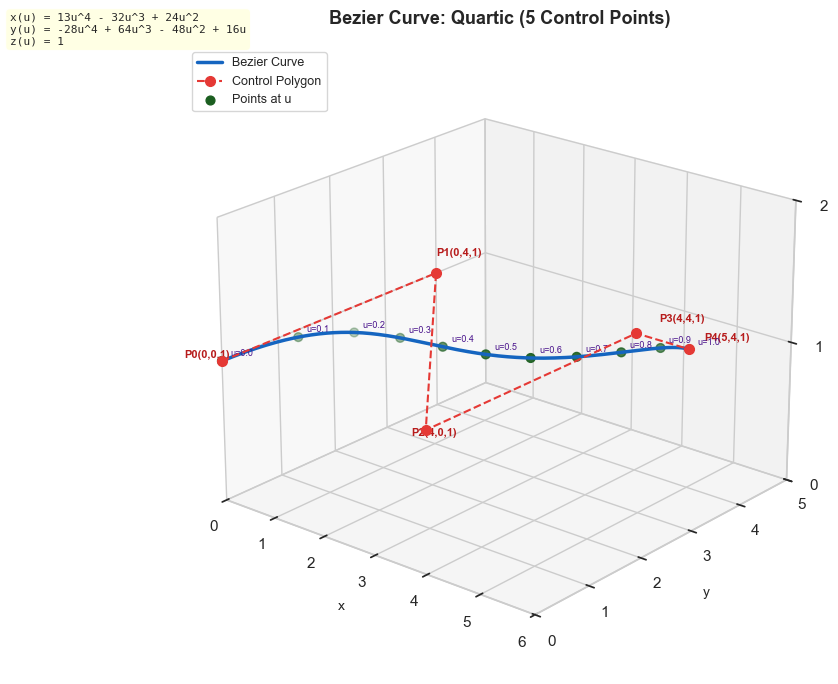

0

In [6]:
main()